Step 1: Load Dataset 

In [1]:
import pandas as pd

df = pd.read_csv("employee_data.csv")

print(df)

   EmployeeID   Age   Salary  Experience Department  Purchased
0           1  25.0  30000.0           1         IT          0
1           2  30.0  40000.0           3         HR          1
2           3   NaN  50000.0           5         IT          1
3           4  40.0      NaN           8    Finance          1
4           5  35.0  70000.0           6         IT          0
5           6  35.0  70000.0           6         IT          0


Step 2: Check Shape

In [2]:
print(df.shape)

(6, 6)


Step 3: Check Data Types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EmployeeID  6 non-null      int64  
 1   Age         5 non-null      float64
 2   Salary      5 non-null      float64
 3   Experience  6 non-null      int64  
 4   Department  6 non-null      str    
 5   Purchased   6 non-null      int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 420.0 bytes


Step 4: Check Missing Values

In [4]:
print(df.isnull().sum())

EmployeeID    0
Age           1
Salary        1
Experience    0
Department    0
Purchased     0
dtype: int64


Step 5: Fix Missing Values
Numerical Columns

In [7]:
df["Age"] = df["Age"].fillna(
    df["Age"].mean()
)

df["Salary"] = df["Salary"].fillna(
    df["Salary"].mean()
)

print(df)
print("\n",df.isnull().sum())

   EmployeeID   Age   Salary  Experience Department  Purchased
0           1  25.0  30000.0           1         IT          0
1           2  30.0  40000.0           3         HR          1
2           3  33.0  50000.0           5         IT          1
3           4  40.0  52000.0           8    Finance          1
4           5  35.0  70000.0           6         IT          0
5           6  35.0  70000.0           6         IT          0

 EmployeeID    0
Age           0
Salary        0
Experience    0
Department    0
Purchased     0
dtype: int64


Step 6: Check Duplicates

In [8]:
print(df.duplicated().sum())

0


Step 7: Handle Duplicates

In [9]:
df = df.drop_duplicates()

Step 8: Check Outliers
Boxplot

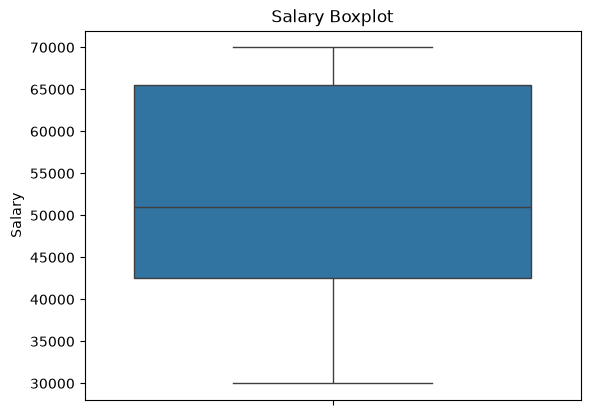

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(y=df["Salary"])

plt.title("Salary Boxplot")
plt.show()

IQR Method

In [16]:
Q1 = df["Salary"].quantile(0.25)

Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

outliers = df[
    (df["Salary"] < lower)|
    (df["Salary"] > upper)
]

print(outliers)


8000.0
100000.0
Empty DataFrame
Columns: [EmployeeID, Age, Salary, Experience, Department, Purchased]
Index: []


Step 9: Visualizations
Histogram: 

Distribution?
Skewed?
Normal?

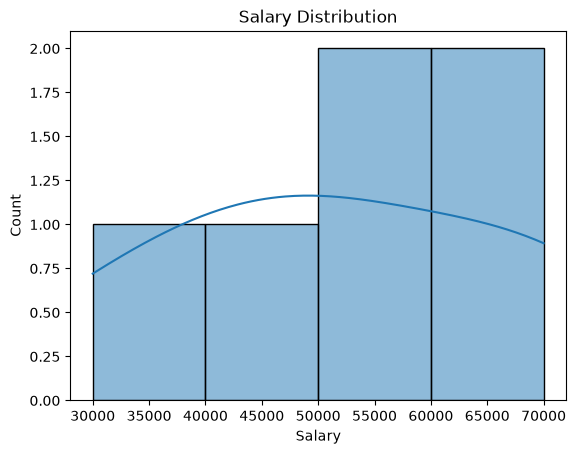

In [17]:
sns.histplot(
    df["Salary"],
    kde=True
)

plt.title("Salary Distribution")

plt.show()

Countplot

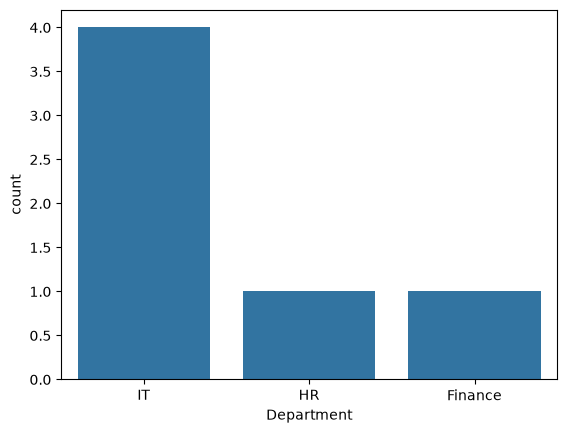

In [18]:
sns.countplot(
    data=df,
    x="Department"
)

plt.show()

Scatterplot

Experience impacts salary?

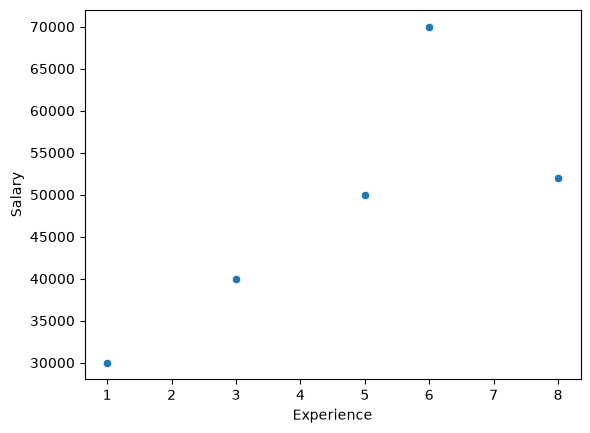

In [ ]:
sns.scatterplot(
    data=df,
    x="Experience",
    y="Salary"
)

plt.show()

Pairplot

Shows every numerical relationship automatically.

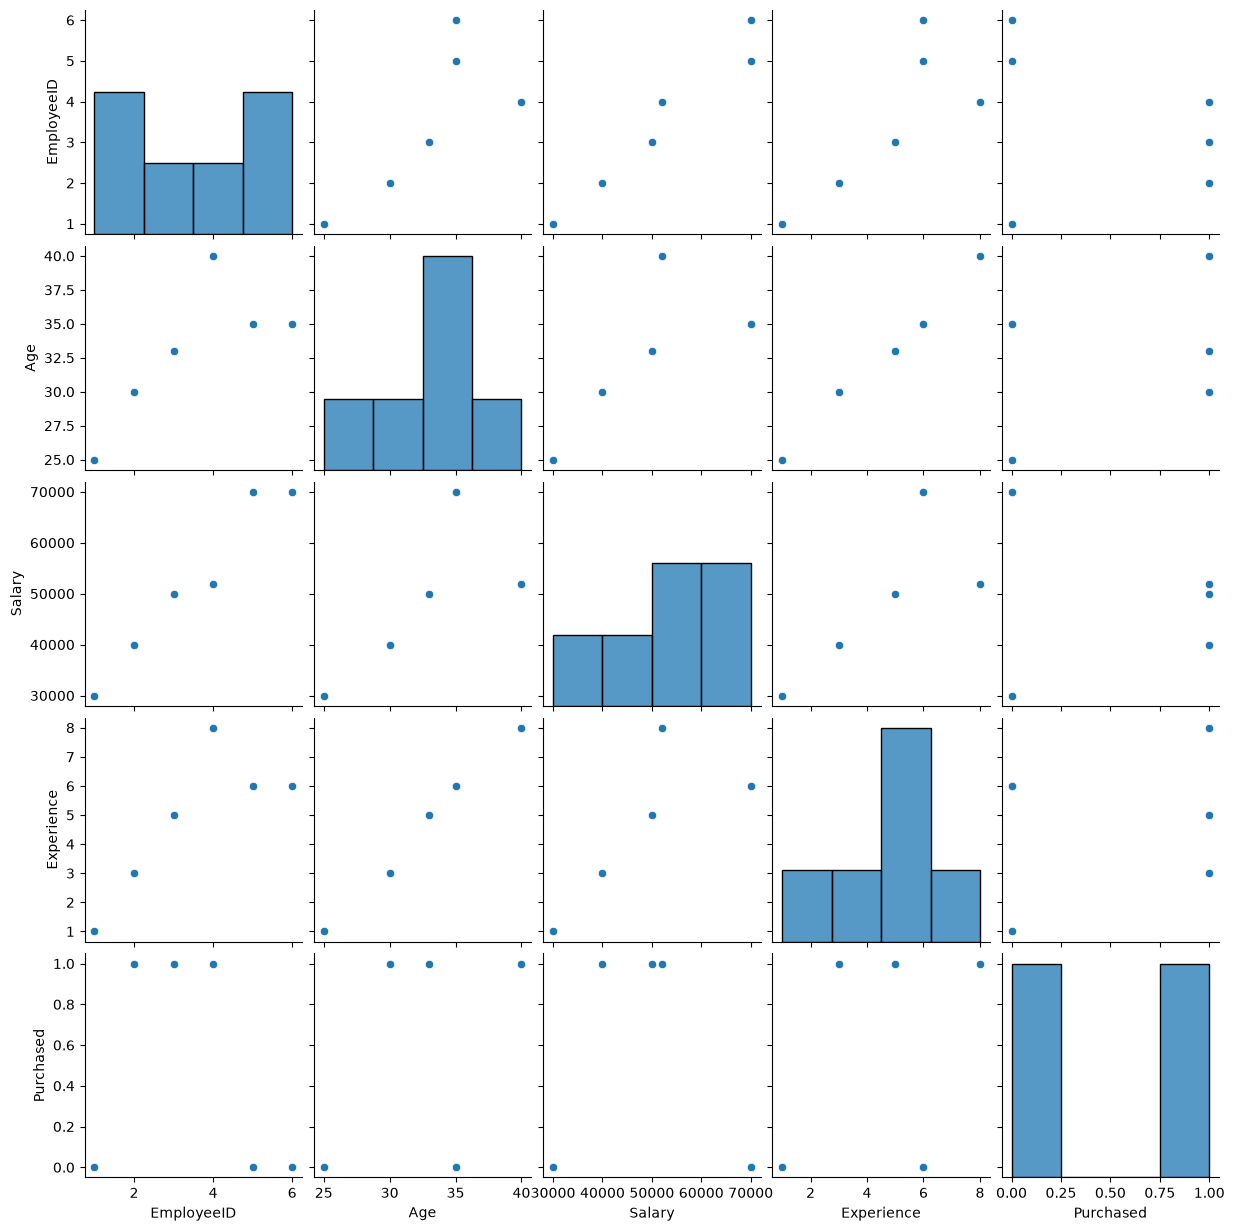

In [20]:
sns.pairplot(df)

plt.show()

Step 10: Correlation Analysis

Strong relationships?
Redundant columns?

Correlation:             EmployeeID       Age    Salary  Experience  Purchased
EmployeeID    1.000000  0.754765  0.975504    0.796421  -0.292770
Age           0.754765  1.000000  0.696212    0.995081   0.286446
Salary        0.975504  0.696212  1.000000    0.744983  -0.319505
Experience    0.796421  0.995081  0.744983    1.000000   0.220564
Purchased    -0.292770  0.286446 -0.319505    0.220564   1.000000




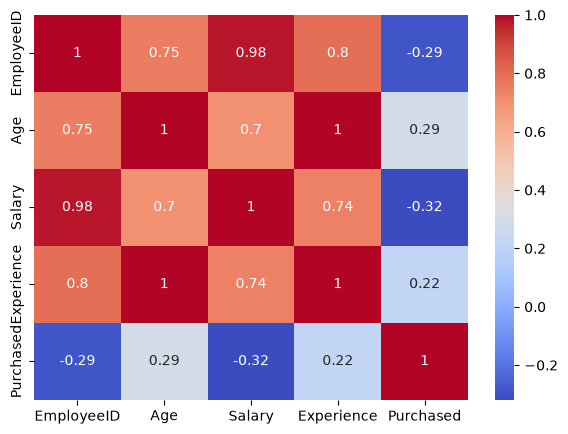

In [22]:
corr = df.corr(
    numeric_only=True
)

print("Correlation:",corr)


#visualize

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
print("\n")
plt.show()

Step 11: Feature Engineering
Drop Unnecessary Columns

EmployeeID doesn't help prediction

In [25]:
df = df.drop(
    "EmployeeID",
    axis=1
)


KeyError: "['EmployeeID'] not found in axis"

Encode Department

In [27]:
df = pd.get_dummies(
    df,
    columns=["Department"],
    dtype=int
)

Scale Numerical Features

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Age","Salary","Experience"]] = (
    scaler.fit_transform(
        df[["Age","Salary","Experience"]]
    )
)

print(df)

        Age    Salary  Experience  Purchased  Department_Finance  \
0 -1.718676 -1.506237   -1.690994          0                   0   
1 -0.644503 -0.821584   -0.808736          1                   0   
2  0.000000 -0.136931    0.073521          1                   0   
3  1.503841  0.000000    1.396908          1                   1   
4  0.429669  1.232376    0.514650          0                   0   
5  0.429669  1.232376    0.514650          0                   0   

   Department_HR  Department_IT  
0              0              1  
1              1              0  
2              0              1  
3              0              0  
4              0              1  
5              0              1  


Step 12: Model Building
Prepare Features and Target

In [33]:
X = df.drop(
    "Purchased",
    axis=1
)

y = df["Purchased"]

Train test split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

Train Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

Prediction

In [37]:
y_pred = model.predict(X_test)

print(y_pred)

[1 1]


Accuracy

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.5
